# 07 · Detector de eventos

**Objetivo:** encender una alarma cuando ocurre un evento (contaminación, falla de cloración,
turbidez en la fuente o falla de pH), lo antes posible y con pocas falsas alarmas, e indicar de qué
tipo es probablemente.

**Cómo se mide** (por episodio, no por lectura, como se recomendó en el notebook 05):

| Métrica | Qué significa |
|---|---|
| eventos detectados | episodios **visibles** en que algún sensor que ve el evento entra en alarma mientras lo ve |
| falsas alarmas por semana | episodios de alarma en que ningún sensor en alarma tiene un evento visible |
| retraso | horas desde que el evento se ve en algún sensor hasta la primera alarma en un sensor que lo ve |
| tipo correcto | el tipo más sugerido durante la alarma coincide con el tipo real |

**Diseño:**

- **Solo con información disponible en operación.** Las lecturas se limpian únicamente con reglas
  que no necesitan etiquetas: presión mínima, rango físico y sensor pegado (`calidad.lecturas_operativas`).
  Las demás fallas del sensor (deriva, picos, ruido) quedan en los datos: el detector tiene que
  aprender a no confundirlas con eventos.
- **Una fila = un sensor en una hora.** El modelo estima la probabilidad de que haya un evento
  visible en ese sensor y de qué tipo (`HistGradientBoostingClassifier` de scikit-learn, con pesos
  por clase por el desbalance).
- **Variables** (`src/detector.py`), según el notebook 05: desviación de cada parámetro respecto a lo
  típico del sensor a esa hora; cambios recientes; cuántos parámetros del sensor se desvían a la vez;
  cuántos sensores de la red se desvían a la vez; desviaciones de la fuente; lluvia reciente.
- **Alarma:** un sensor entra en alarma si su probabilidad de evento supera un **umbral** durante
  varias **horas seguidas** (confirmación). El umbral y las horas se eligen en validación con una
  regla fija: el máximo de eventos detectados con **a lo sumo 1 falsa alarma por semana**.

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix

from src import carga, calidad, detector
from src.graficos import estilo, guardar, COLORES, GRIS

estilo()
pd.set_option("display.precision", 2)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

crudo = carga.cargar_todo()
t15 = calidad.lecturas_operativas(crudo)
h = detector.horario(t15)
h["evento_red"] = crudo["evento_red"].resample("1h").max()
tabla, tipicos = detector.tabla(h)
X = detector.columnas_entrada(tabla)

entr = (tabla["particion"] == "entrenamiento").values
val = (tabla["particion"] == "validacion").values
prueba = (tabla["particion"] == "prueba").values
PERIODO = {"validación": ("2026-05-01", "2026-09-01"), "prueba": ("2026-09-01", "2027-01-01")}
NOMBRE = {"contaminacion": "Contaminación", "falla_cloro": "Falla de cloración",
          "turbidez_fuente": "Turbidez en la fuente", "falla_ph": "Falla de pH"}
TIPOS = list(NOMBRE)
COLOR = {"contaminacion": COLORES[7], "falla_cloro": COLORES[1], "turbidez_fuente": COLORES[3], "falla_ph": COLORES[6]}
print(f"Tabla: {len(tabla):,} filas · {len(X)} variables")
print("Clases en entrenamiento:", tabla.loc[entr, "clase"].map(carga.TIPOS_EVENTO).value_counts().to_dict())

Tabla: 367,920 filas · 62 variables
Clases en entrenamiento: {'normal': 228402, 'falla_ph': 8419, 'falla_cloro': 3035, 'contaminacion': 2343, 'turbidez_fuente': 2241}


## 1. Entrenamiento

In [2]:
t0 = time.time()
mod = detector.entrenar(tabla, X, entr)
print(f"{mod.n_iter_} árboles · {time.time() - t0:.0f} s")
p_evento, tipo = detector.probabilidades(mod, tabla, X)
tipo_ancho = pd.DataFrame({"fecha": tabla["fecha"], "nodo": tabla["nodo"], "tipo": tipo}) \
               .pivot(index="fecha", columns="nodo", values="tipo")

104 árboles · 30 s


## 2. Elección del umbral y la confirmación (validación)

Se prueban umbrales de 0,5 a 0,95 con 1, 2 y 3 horas de confirmación (cada punto del gráfico es un umbral). La regla de elección se fija antes de ver los resultados: **máximo
de eventos detectados con a lo sumo 1 falsa alarma por semana**; si hay empate, menos falsas alarmas;
si sigue el empate, menos retraso.

In [3]:
filas = []
for confirmar in [1, 2, 3]:
    for umbral in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        A = detector.alarmas_sensor(tabla[val], p_evento[val], umbral, confirmar)
        det, alarmas, r = detector.evaluar(h, A, *PERIODO["validación"], tipo_ancho)
        filas.append({"confirmación (h)": confirmar, "umbral": umbral,
                      "detectados": r["detectados"], "de": r["episodios visibles"],
                      "falsas por semana": r["falsas por semana"], "retraso mediano (h)": det["retraso_h"].median()})
grilla = pd.DataFrame(filas)
candidatas = grilla[grilla["falsas por semana"] <= 1.0].sort_values(
    ["detectados", "falsas por semana", "retraso mediano (h)"], ascending=[False, True, True])
elegida = candidatas.iloc[0]
UMBRAL, CONFIRMAR = float(elegida["umbral"]), int(elegida["confirmación (h)"])
print(f"Elegido: umbral {UMBRAL}, confirmación {CONFIRMAR} h")
grilla.pivot_table(index="confirmación (h)", columns="umbral", values=["detectados", "falsas por semana"]).round(2)

Elegido: umbral 0.8, confirmación 3 h


detectados                               falsas por semana                              
umbral                 0.50  0.60  0.70  0.80  0.90  0.95              0.50  0.60  0.70  0.80  0.90  0.95
confirmación (h)                                                                                         
1                      21.0  21.0  21.0  21.0  21.0  19.0              5.34  3.75  2.84  1.94  1.11  0.62
2                      21.0  21.0  21.0  21.0  20.0  19.0              2.08  1.46  1.04  1.04  0.21  0.49
3                      21.0  21.0  21.0  21.0  19.0  19.0              1.11  0.69  0.49  0.35  0.21  0.35

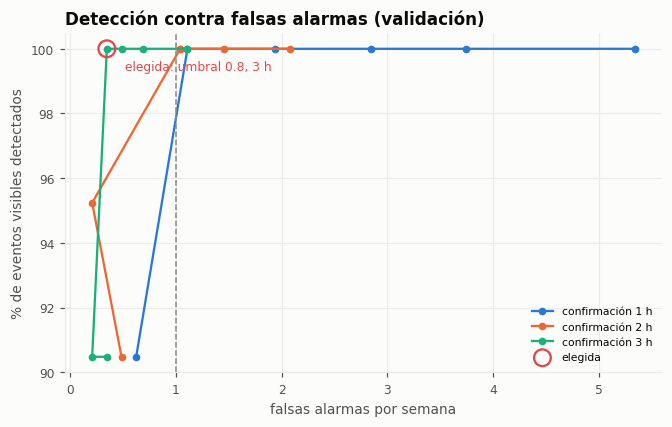

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for k, confirmar in enumerate([1, 2, 3]):
    g = grilla[grilla["confirmación (h)"] == confirmar]
    ax.plot(g["falsas por semana"], 100 * g["detectados"] / g["de"], "o-", color=COLORES[k], ms=4,
            label=f"confirmación {confirmar} h")
ax.axvline(1, color=GRIS, ls="--", lw=1)
ax.scatter([elegida["falsas por semana"]], [100 * elegida.detectados / elegida.de], s=120,
           facecolors="none", edgecolors=COLORES[7], linewidths=1.5, zorder=5, label="elegida")
ax.set_xlabel("falsas alarmas por semana"); ax.set_ylabel("% de eventos visibles detectados")
ax.annotate(f"elegida: umbral {UMBRAL:g}, {CONFIRMAR} h", (elegida["falsas por semana"], 100 * elegida.detectados / elegida.de),
            xytext=(12, -14), textcoords="offset points", fontsize=8, color=COLORES[7])
ax.set_title("Detección contra falsas alarmas (validación)")
ax.legend(fontsize=7)
guardar(fig, "07_umbral"); plt.show()

## 3. Evaluación final en el periodo de prueba

In [5]:
A_prueba = detector.alarmas_sensor(tabla[prueba], p_evento[prueba], UMBRAL, CONFIRMAR)
det, alarmas, r = detector.evaluar(h, A_prueba, *PERIODO["prueba"], tipo_ancho)
por_tipo = det.groupby("tipo").agg(episodios=("detectado", "size"), detectados=("detectado", "sum"),
                                   retraso_mediano_h=("retraso_h", "median"))
por_tipo["% detectados"] = 100 * por_tipo["detectados"] / por_tipo["episodios"]
detectados_ = det[det.detectado]
por_tipo["tipo correcto"] = {t_: f"{(d_['tipo_sugerido'] == t_).sum()} de {len(d_)}"
                             for t_, d_ in detectados_.groupby("tipo")}
por_tipo = por_tipo.loc[[x for x in TIPOS if x in por_tipo.index]].rename(index=NOMBRE)
total_red = (detector.episodios(h.loc[PERIODO["prueba"][0]:"2026-12-31", "evento_red"].fillna(0).astype(int)))
print(f"Eventos en la red en el periodo: {len(total_red)} · visibles en algún sensor: {r['episodios visibles']}")
print(f"Detectados: {r['detectados']} de {r['episodios visibles']} visibles "
      f"({100 * r['detectados'] / r['episodios visibles']:.0f} %)")
print(f"Alarmas: {r['alarmas']} · falsas: {r['falsas alarmas']} ({r['falsas por semana']:.2f} por semana)")
print(f"Retraso mediano: {det['retraso_h'].median():.0f} h · tipo correcto: "
      f"{(det.tipo_sugerido == det.tipo)[det.detectado].sum()} de {det.detectado.sum()}")
por_tipo

Eventos en la red en el periodo: 35 · visibles en algún sensor: 27
Detectados: 25 de 27 visibles (93 %)
Alarmas: 59 · falsas: 10 (0.77 por semana)
Retraso mediano: 2 h · tipo correcto: 23 de 25


,episodios,detectados,retraso_mediano_h,% detectados,tipo correcto
tipo,,,,,
Contaminación,14,12,2.0,85.71,11 de 12
Falla de cloración,5,5,2.0,100.00,5 de 5
Turbidez en la fuente,3,3,2.0,100.00,2 de 3
Falla de pH,5,5,2.0,100.00,5 de 5


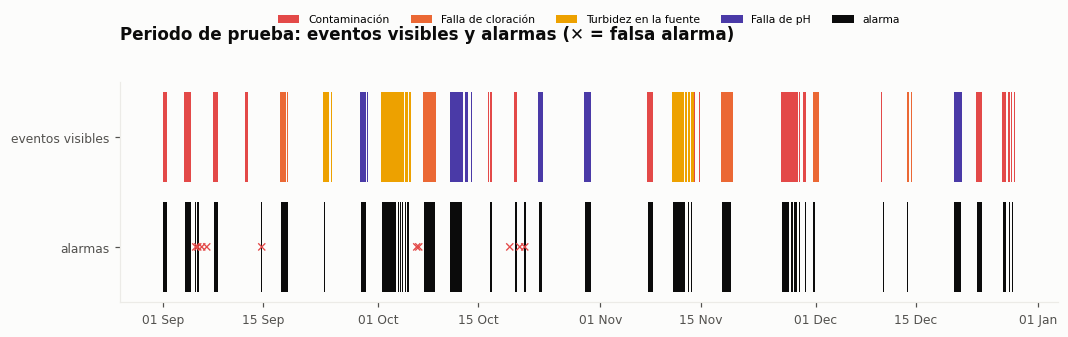

In [6]:
inicio, fin = pd.Timestamp(PERIODO["prueba"][0]), pd.Timestamp("2026-12-31 23:00")
E = h.loc[inicio:fin, [f"evento_{n}" for n in A_prueba.columns]].fillna(0)
red_alarma = A_prueba.loc[inicio:fin].any(axis=1)
fig, ax = plt.subplots(figsize=(11, 2.6))
for k, tipo_ in enumerate(TIPOS):
    codigo = TIPOS.index(tipo_) + 1
    vis = (E == codigo).any(axis=1)
    ax.fill_between(vis.index, 1.1, 2.0, where=vis.values, color=COLOR[tipo_], step="post", lw=0,
                    label=NOMBRE[tipo_])
ax.fill_between(red_alarma.index, 0, 0.9, where=red_alarma.values, color="#0b0b0b", step="post", lw=0,
                label="alarma")
for _, a in alarmas[alarmas.falsa].iterrows():
    ax.annotate("✕", (a.inicio, 0.45), color=COLORES[7], fontsize=9, ha="center", va="center", fontweight="bold")
ax.set_yticks([0.45, 1.55]); ax.set_yticklabels(["alarmas", "eventos visibles"])
ax.set_ylim(-0.1, 2.1); ax.grid(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(ncol=5, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, 1.35))
ax.set_title("Periodo de prueba: eventos visibles y alarmas (✕ = falsa alarma)", pad=28)
guardar(fig, "07_linea_tiempo_prueba"); plt.show()

### ¿Qué tan bien identifica el tipo?

Para cada hora en que un sensor está en alarma y realmente ve un evento: tipo real contra tipo
sugerido por el modelo.

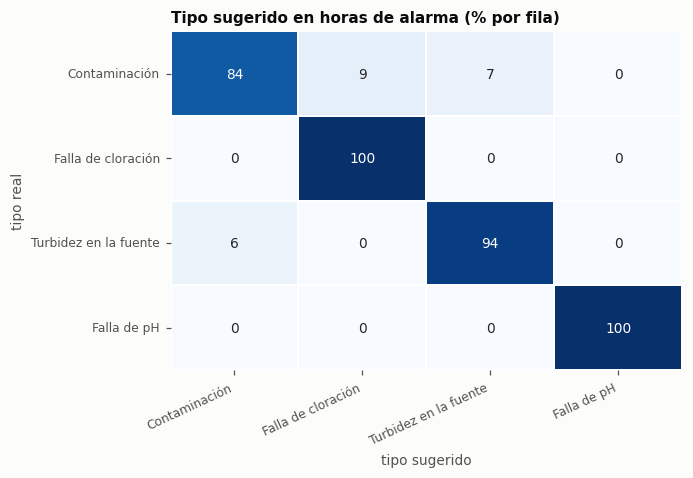

In [7]:
idx = A_prueba.index
E_p = h.loc[idx, [f"evento_{n}" for n in A_prueba.columns]].fillna(0).astype(int)
E_p.columns = A_prueba.columns
m = A_prueba.values & (E_p.values > 0)
reales = E_p.values[m]
sugeridos = tipo_ancho.reindex(index=idx, columns=A_prueba.columns).values[m].astype(int)
cm = confusion_matrix(reales, sugeridos, labels=[1, 2, 3, 4])
cm = pd.DataFrame(cm, index=[NOMBRE[t] for t in TIPOS], columns=[NOMBRE[t] for t in TIPOS])
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm.div(cm.sum(axis=1), axis=0) * 100, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar=False, ax=ax, linewidths=1, linecolor="white")
ax.set_xlabel("tipo sugerido"); ax.set_ylabel("tipo real"); ax.grid(False)
ax.set_title("Tipo sugerido en horas de alarma (% por fila)", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
guardar(fig, "07_confusion_tipo"); plt.show()

## 4. ¿De dónde vienen las falsas alarmas y qué se escapa?

**Falsas alarmas:** para cada una se revisa si el sensor en alarma tenía una falla del instrumento
(usando las columnas `falla_*`, que el detector no vio) o si coincidía con lluvia.

**Eventos no detectados:** cuántos sensores los ven y cuánto se aparta el cloro de lo típico.

In [8]:
F = crudo[[c for c in crudo.columns if c.startswith("falla_")]].resample("1h").max()
lluvia24 = h["lluvia_mm_h"].rolling(24, min_periods=1).sum()
causas = []
for _, a in alarmas[alarmas.falsa].iterrows():
    tramo = A_prueba.loc[a.inicio:a.fin]
    sensores = list(tramo.columns[tramo.any()])
    con_falla = any(F.loc[a.inicio:a.fin, [c for c in F.columns if c.endswith("_" + n)]].isin([1, 2, 3, 4]).values.any()
                    for n in sensores)
    causas.append({"inicio": a.inicio, "horas": a.horas, "sensores": ", ".join(sensores),
                   "falla del sensor": con_falla, "lluvia 24 h (mm)": round(float(lluvia24.loc[a.inicio:a.fin].max()), 1)})
causas = pd.DataFrame(causas)
causas

,inicio,horas,sensores,falla del sensor,lluvia 24 h (mm)
0,2026-09-05 11:00:00,6.0,"J1058, J150, J224, J237, J27, J284, J345, J360...",False,25.9
1,2026-09-05 20:00:00,8.0,"J123, J345, N6",False,26.8
2,2026-09-06 09:00:00,1.0,J144,False,26.5
3,2026-09-07 00:00:00,1.0,J123,False,23.9
4,2026-09-14 18:00:00,2.0,J379,False,0.9
5,2026-10-06 08:00:00,1.0,J345,False,0.0
6,2026-10-06 13:00:00,1.0,J123,False,1.5
7,2026-10-19 07:00:00,2.0,J144,False,6.4
8,2026-10-20 17:00:00,1.0,J144,False,1.0
9,2026-10-21 10:00:00,6.0,J144,False,17.1


In [9]:
no_det = det[~det.detectado].copy()
if len(no_det):
    desv_cl2 = []
    for _, e in no_det.iterrows():
        ventana = slice(e.inicio, e.inicio + pd.Timedelta(hours=48))
        sub = tabla[(tabla["fecha"] >= e.inicio) & (tabla["fecha"] <= e.inicio + pd.Timedelta(hours=48)) &
                    (tabla["clase"] > 0)]
        desv_cl2.append(sub["desvio_CL2"].min() if len(sub) else np.nan)
    no_det["mayor caída de cloro vista (mg/L)"] = desv_cl2
    no_det["máx. probabilidad de evento"] = [
        float(p_evento[(tabla["fecha"] >= e.inicio).values & (tabla["fecha"] <= e.inicio + pd.Timedelta(hours=48)).values
                       & (tabla["clase"] > 0).values].max()) for _, e in no_det.iterrows()]
no_det[["inicio", "tipo", "sensores_que_lo_ven"] + [c for c in no_det.columns if c.startswith(("mayor", "máx"))]]

,inicio,tipo,sensores_que_lo_ven,mayor caída de cloro vista (mg/L),máx. probabilidad de evento
17,2026-11-14 01:00:00,contaminacion,2,-0.19,0.95
22,2026-12-10 16:00:00,contaminacion,1,0.07,0.01


## 5. Variables más importantes

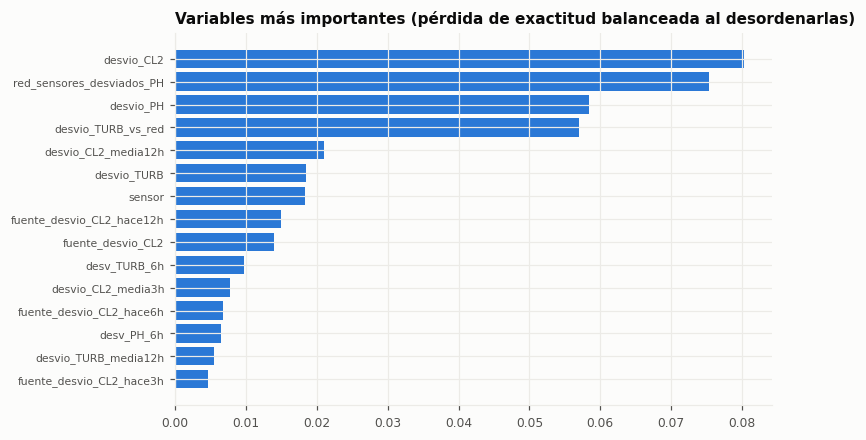

In [10]:
import warnings
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore", message="y_pred contains classes not in y_true")   # validación no tiene turbidez en la fuente
muestra = tabla[val].sample(20000, random_state=0)
muestra = pd.concat([muestra, tabla[val & (tabla["clase"] > 0).values]]).drop_duplicates()
r_imp = permutation_importance(mod, muestra[X], muestra["clase"], n_repeats=3, random_state=0,
                               scoring="balanced_accuracy")
imp = pd.Series(r_imp.importances_mean, index=X).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.barh(imp.index[::-1], imp.values[::-1], color=COLORES[0])
ax.set_title("Variables más importantes (pérdida de exactitud balanceada al desordenarlas)", fontsize=10)
ax.tick_params(axis="y", labelsize=7)
guardar(fig, "07_importancia_variables"); plt.show()

## 6. Guardar el detector

In [11]:
carpeta = Path.cwd().parent / "modelos"
carpeta.mkdir(exist_ok=True)
joblib.dump({"modelo": mod, "columnas": X, "tipicos": tipicos, "umbral": UMBRAL, "confirmar_h": CONFIRMAR,
             "sensores": list(A_prueba.columns)}, carpeta / "detector_eventos.joblib", compress=3)
print("Guardado:", carpeta / "detector_eventos.joblib",
      f"({(carpeta / 'detector_eventos.joblib').stat().st_size / 1e6:.1f} MB)")

Guardado: /tmp/claude-0/prueba/Modelo_calidad_agua/modelos/detector_eventos.joblib (0.9 MB)


## 7. Conclusiones

**Resultado en el periodo de prueba (sep–dic 2026)**, con umbral 0,8 y confirmación de 3 h
(elegidos en validación con la regla fijada de antemano):

| | Resultado |
|---|---|
| Eventos visibles detectados | **25 de 27 (93 %)** |
| Contaminaciones | 12 de 14 (86 %) |
| Falla de cloración, turbidez en la fuente, falla de pH | 13 de 13 (100 %) |
| Falsas alarmas | **0,77 por semana** (10 en 4 meses) |
| Retraso mediano | 2 h desde que el evento es visible |
| Tipo correcto | 23 de 25 eventos detectados |

En el periodo hubo 35 eventos en la red; 8 no los ve ningún sensor y no se pueden detectar con esta
red (notebook 05).

**Lo que muestra el detector**

1. **Detecta casi todo lo que los sensores pueden ver.** Todos los eventos de la fuente y 12 de 14
   contaminaciones, con 2 h de retraso típico. Ese retraso viene sobre todo de la confirmación: la
   alarma espera 3 h seguidas de probabilidad alta para no dispararse por un dato suelto.
2. **No confunde fallas del sensor con eventos.** Ninguna de las 10 falsas alarmas coincide con una
   falla del instrumento, aunque el detector trabaja con datos que todavía traen deriva, picos y
   ruido. Las variables de "cuántos parámetros y cuántos sensores se desvían a la vez" (notebook 05)
   hacen ese trabajo.
3. **Las falsas alarmas tienen dos orígenes:**
   - **Lluvia fuerte:** cuatro en la primera semana de septiembre, con 24–27 mm en 24 h, que suben
     la turbidez en varios sensores a la vez.
   - **Sensores del extremo de la red:** J144 y J123, donde el cloro ya es bajo y variable.

   Las dos son mejorables: la primera con el pronóstico de lluvia, la segunda con un umbral
   propio para esos sensores.
4. **Las contaminaciones que se escapan son las más pequeñas.** Una la ven 2 sensores, con una caída
   de cloro de 0,19 mg/L: la probabilidad llegó a 0,95, pero no se mantuvo 3 h seguidas. La otra la
   ve un solo sensor sin caída de cloro apreciable, prácticamente indistinguible de lo normal.
5. **El tipo se identifica bien.** En las horas de alarma, falla de cloración y falla de pH se
   identifican el 100 % de las veces, turbidez en la fuente el 94 % y contaminación el 84 %. La
   confusión que queda es entre contaminación y los otros dos eventos que mueven cloro o turbidez.
6. **Lo que más usa el modelo** es la desviación del cloro respecto a lo típico, cuántos sensores
   tienen el pH desviado, la desviación del pH y la turbidez comparada con el resto de la red.

**Precauciones**

- La validación solo tiene 21 eventos visibles (y ninguno de turbidez en la fuente), así que el
  umbral se eligió con pocos casos. El resultado que vale es el de la prueba, que es comparable o
  mejor, y eso indica que la elección no quedó ajustada a la validación.
- Las probabilidades del modelo están sesgadas hacia "evento" por los pesos de clase. Sirven para
  ordenar y poner un umbral, pero no deben leerse como probabilidades reales.

**Siguientes pasos**

- Usar el pronóstico y la lluvia para no alarmar por turbidez que la lluvia explica.
- Evaluar un umbral por sensor para los del extremo de la red.
- Llevar el detector y el pronóstico al servicio en tiempo real: el dashboard y las alertas por
  WhatsApp.